# LIME phishing detection notebook

This notebook is the full mini-pipeline: download phishing emails, clean labels, train a DistilRoBERTa classifier, explain one prediction with LIME, and check whether important tokens actually affect the model.

The task is binary: `1` means phishing and `0` means safe.

Use **Runtime -> Change runtime type -> GPU** before running.


In [ ]:
!pip install -q kagglehub "datasets>=2.18.0" "numpy>=1.26.0" "pandas>=2.2.0" "scikit-learn>=1.4.0" "torch>=2.2.0" "transformers>=4.46.0" "accelerate>=0.28.0" "matplotlib>=3.8.0"

In [ ]:
import html
import json
import random
import re
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from IPython.display import HTML, display
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import DataCollatorWithPadding, Trainer, TrainingArguments, set_seed

SEED = 42
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 256
OUTPUT_DIR = Path("artifacts/model")
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 1. Download and prepare data

KaggleHub pulls the public dataset from `subhajournal/phishingemails`. The CSV has email text and a label. We keep those fields, drop missing/blank text, map phishing-like labels to `1`, and create stratified train/validation/test splits.

The printed label counts show class balance. The split sizes confirm the 80/10/10 setup used for training, model selection, and final testing.


In [ ]:
dataset_dir = Path(kagglehub.dataset_download("subhajournal/phishingemails"))
csv_path = next(dataset_dir.rglob("*.csv"))
raw_df = pd.read_csv(csv_path).rename(columns=str.strip)

df = raw_df[["Email Text", "Email Type"]].dropna().rename(columns={
    "Email Text": "text",
    "Email Type": "email_type",
})
df["text"] = df["text"].astype(str).str.strip()
df["label"] = df.pop("email_type").astype(str).str.lower().str.contains("phish|spam|malicious", regex=True).astype(int)
df = df[df["text"].ne("")].reset_index(drop=True)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

print("CSV:", csv_path)
print("Labels:", df["label"].value_counts().sort_index().to_dict())
print("Splits:", {"train": len(train_df), "val": len(val_df), "test": len(test_df)})


100%|██████████| 18.0M/18.0M [00:01<00:00, 17.6MB/s]

Extracting files...


CSV: /root/.cache/kagglehub/datasets/subhajournal/phishingemails/versions/1/Phishing_Email.csv
Labels: {0: 11322, 1: 7309}
Splits: {'train': 14904, 'val': 1863, 'test': 1864}


,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0


## 2. Train DistilRoBERTa

DistilRoBERTa turns each email into transformer tokens and learns a two-class head on top. We train for one epoch to keep the notebook practical; increase `num_train_epochs` for a slower run that may improve scores.

The metrics we use are accuracy, precision, recall, and F1. F1 is especially useful here because the dataset has more safe than phishing emails.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def preprocess(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_pandas(train_df, preserve_index=False).map(preprocess, batched=True)
val_ds = Dataset.from_pandas(val_df, preserve_index=False).map(preprocess, batched=True)
test_ds = Dataset.from_pandas(test_df, preserve_index=False).map(preprocess, batched=True)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    seed=SEED,
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()
test_metrics = trainer.evaluate(eval_dataset=test_ds)
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))
test_metrics


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/1864 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.054473,0.110972,0.968331,0.943272,0.978112,0.960376


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.11191196739673615,
 'eval_accuracy': 0.9688841201716738,
 'eval_precision': 0.948069241011984,
 'eval_recall': 0.9740082079343365,
 'eval_f1': 0.9608636977058029,
 'eval_runtime': 15.4491,
 'eval_samples_per_second': 120.654,
 'eval_steps_per_second': 3.819,
 'epoch': 1.0}

## 3. LIME explanation

LIME explains one prediction, not the whole model. For the selected email it creates many perturbed copies, removes different words, asks DistilRoBERTa for each phishing probability, gives more weight to copies close to the original, and fits a small weighted ridge regression.

Read the weights locally: positive tokens pushed this email toward phishing, negative tokens pushed it toward safe. A word can receive a different weight in another email.


In [ ]:
WORD_RE = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)

def tokenize_words(text):
    return WORD_RE.findall(text)

def join_tokens(tokens):
    return " ".join(tokens)

def predict_phishing_proba(texts, batch_size=32):
    model.eval()
    model.to(device)
    texts = list(texts)
    probs = []
    for i in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts[i:i + batch_size],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            logits = model(**encoded).logits
        probs.append(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(probs)

class LimeTextExplainer:
    def __init__(self, predict_fn, kernel_width=25.0, num_samples=3000, random_seed=42):
        self.predict_fn = predict_fn
        self.kernel_width = kernel_width
        self.num_samples = num_samples
        self.random_seed = random_seed

    def explain_instance(self, text, num_features=10):
        rng = np.random.default_rng(self.random_seed)
        tokens = tokenize_words(text)
        masks = rng.binomial(1, 0.5, size=(self.num_samples, len(tokens)))
        masks = masks[masks.sum(axis=1) > 0]
        texts = [join_tokens([token for token, keep in zip(tokens, mask) if keep]) for mask in masks]
        y = self.predict_fn(texts)
        distances = np.sum(1 - masks, axis=1)
        weights = np.exp(-(distances ** 2) / (self.kernel_width ** 2))
        x = StandardScaler().fit_transform(masks)
        coef = Ridge(alpha=1.0).fit(x, y, sample_weight=weights).coef_
        contributions = sorted(
            ({"token": token, "weight": float(weight), "position": i} for i, (token, weight) in enumerate(zip(tokens, coef))),
            key=lambda item: abs(item["weight"]),
            reverse=True,
        )
        probability = float(self.predict_fn([text])[0])
        return {
            "text": text,
            "tokens": tokens,
            "probability": probability,
            "prediction": "phishing" if probability >= 0.5 else "safe",
            "contributions": contributions,
            "top": contributions[:num_features],
        }

explainer = LimeTextExplainer(predict_phishing_proba, num_samples=3000, random_seed=SEED)


The next cell gives five phishing-style examples and five safe examples.

In [ ]:
PHISHING_EXAMPLES = [
    "Your account has been suspended. Click here to verify your identity immediately.",
    "Unusual login activity was detected; confirm your password now to avoid account closure.",
    "You have an unpaid invoice and must open the attached file within 24 hours.",
    "Your mailbox storage is full, so re-enter your credentials to keep receiving email.",
    "Congratulations, you won a refund; submit your bank details to claim the payment.",
]

SAFE_EXAMPLES = [
    "The project meeting has moved to Thursday at 10 AM in conference room B.",
    "Please review the attached agenda before tomorrow's team planning session.",
    "Your monthly statement is available in the official banking app.",
    "Thanks for your order; the package is scheduled to arrive on Friday.",
    "The IT department will perform scheduled maintenance this weekend.",
]


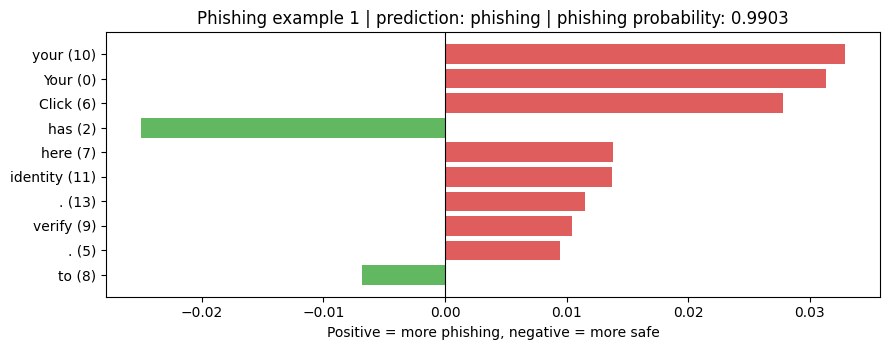

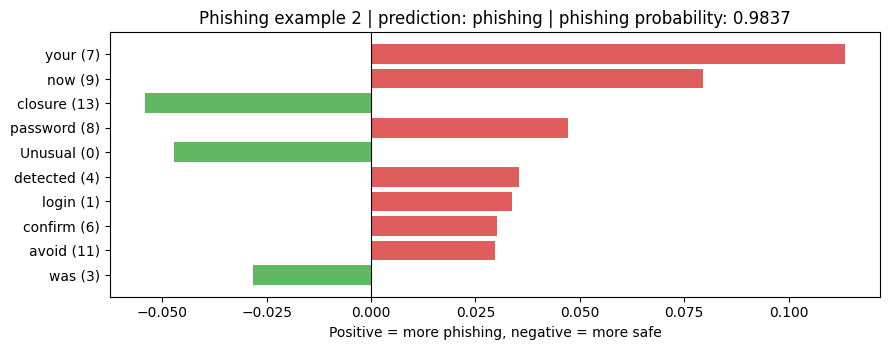

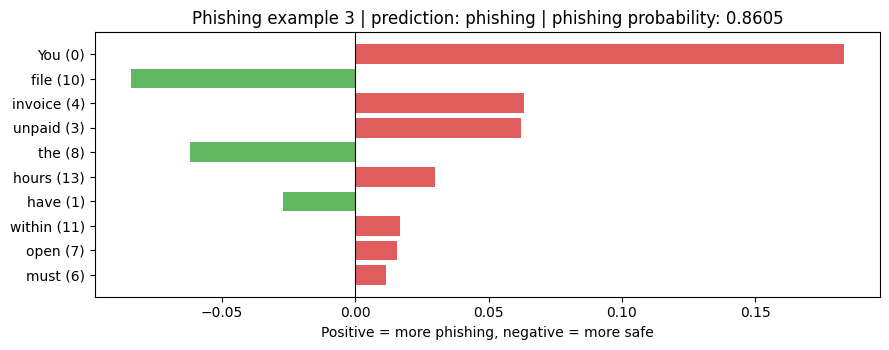

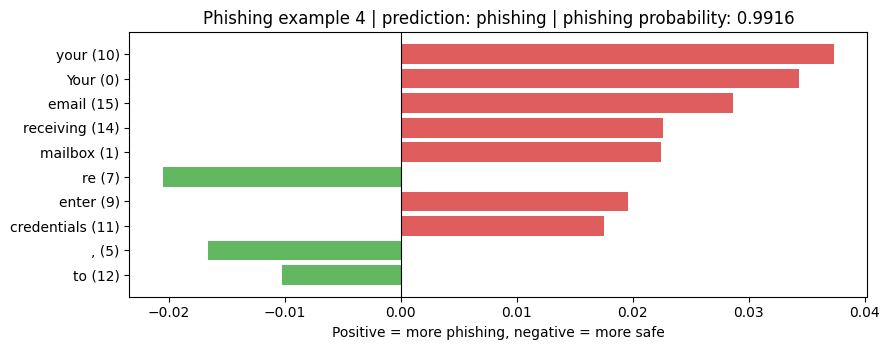

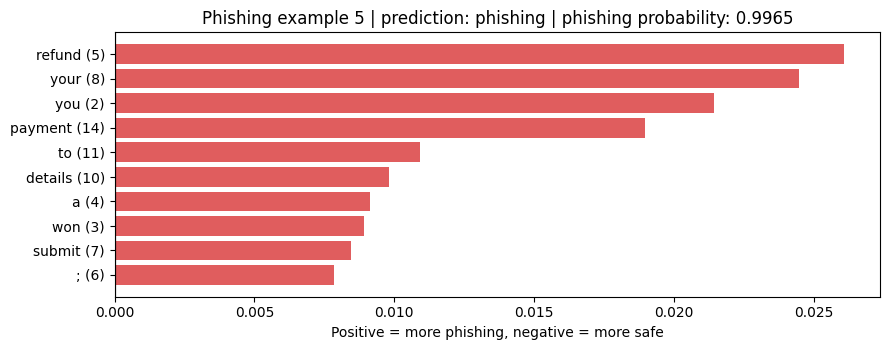

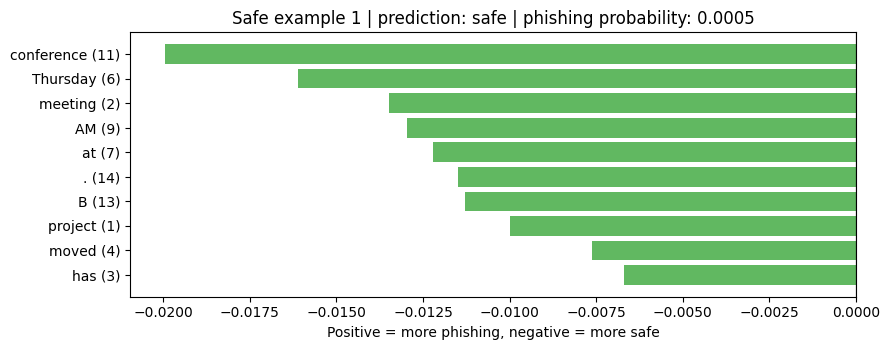

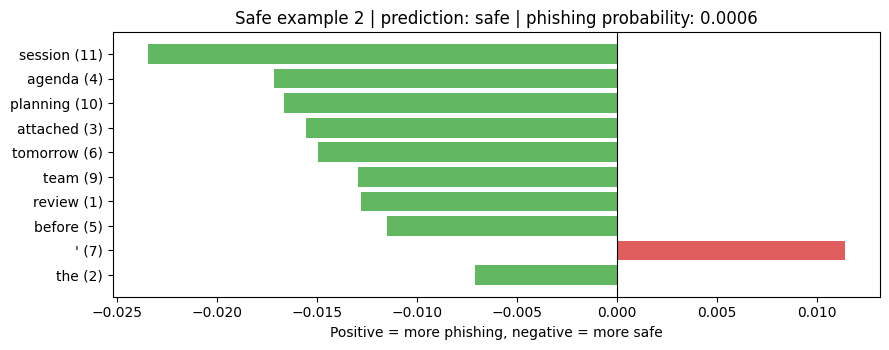

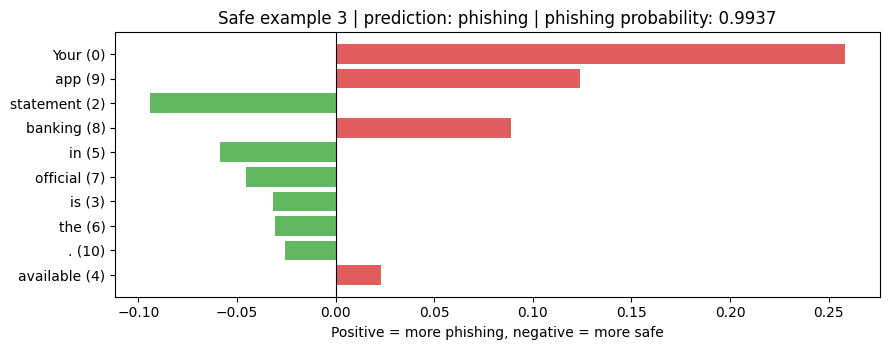

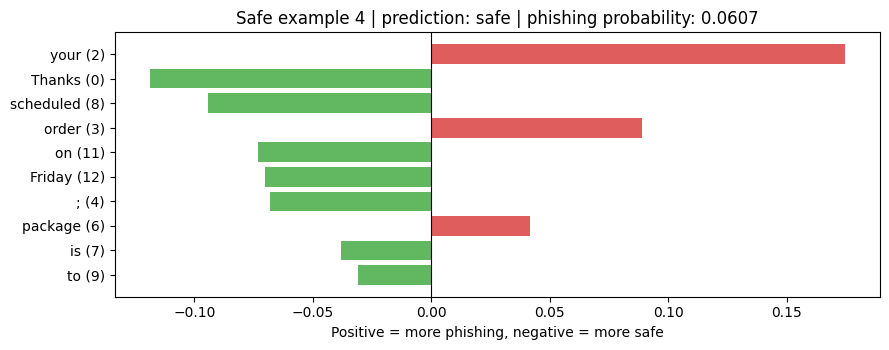

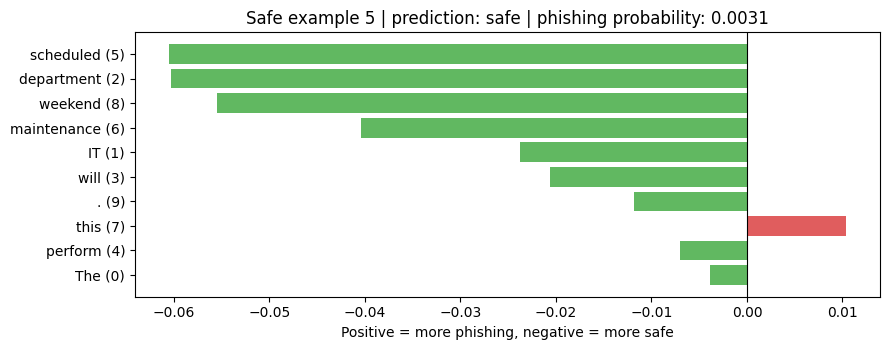

In [ ]:
import html

import matplotlib.pyplot as plt
from IPython.display import HTML, display

SHOWCASE_NUM_SAMPLES = 300

if "explainer" not in globals():
    import torch
    from scripts.explain import create_predict_fn, load_model_and_tokenizer
    from src.lime_text import LimeTextExplainer

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer, model = load_model_and_tokenizer("artifacts/model", device)
    predict_fn = create_predict_fn(model, tokenizer, device, max_length=256, batch_size=32)
    explainer = LimeTextExplainer(
        predict_fn=predict_fn,
        num_samples=SHOWCASE_NUM_SAMPLES,
        random_seed=42,
    )
else:
    explainer.num_samples = SHOWCASE_NUM_SAMPLES

def explanation_contributions(explanation):
    return explanation.get("contributions", explanation.get("all_contributions", []))

def explanation_tokens(explanation):
    return explanation.get("tokens", [])

def explanation_probability(explanation):
    return explanation.get("probability", explanation.get("original_probability"))

def explanation_prediction(explanation):
    return explanation.get("prediction", explanation.get("predicted_class", "unknown"))

def plot_lime_explanation(explanation, title, max_tokens=10):
    top = explanation_contributions(explanation)[:max_tokens]
    labels = [f"{item['token']} ({item['position']})" for item in top][::-1]
    weights = [item["weight"] for item in top][::-1]
    colors = ["#d62728" if weight > 0 else "#2ca02c" for weight in weights]

    plt.figure(figsize=(9, 3.6))
    plt.barh(labels, weights, color=colors, alpha=0.75)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(title)
    plt.xlabel("Positive = more phishing, negative = more safe")
    plt.tight_layout()
    plt.show()

def show_highlighted_text(explanation, max_tokens=16):
    weights_by_position = {
        item["position"]: item["weight"]
        for item in explanation_contributions(explanation)[:max_tokens]
    }
    max_abs = max([abs(weight) for weight in weights_by_position.values()] or [1.0])
    spans = []
    for index, token in enumerate(explanation_tokens(explanation)):
        weight = weights_by_position.get(index, 0.0)
        color = "214, 39, 40" if weight > 0 else "44, 160, 44" if weight < 0 else "238, 238, 238"
        alpha = 0.15 + 0.55 * abs(weight) / max_abs if weight else 1.0
        spans.append(
            f"<span style='background:rgba({color},{alpha:.2f});padding:2px 7px;"
            f"margin:3px;border-radius:4px;display:inline-block'>{html.escape(token)}</span>"
        )
    display(HTML("<div style='font-family:Arial,sans-serif;font-size:18px;line-height:2.2'>" + " ".join(spans) + "</div>"))

def show_lime_example(label, index, text):
    explanation = explainer.explain_instance(text, num_features=10)
    probability = explanation_probability(explanation)
    prediction = explanation_prediction(explanation)
    title = f"{label} example {index} | prediction: {prediction} | phishing probability: {probability:.4f}"
    display(HTML(f"<h3 style='font-family:Arial,sans-serif;margin:18px 0 8px'>{html.escape(title)}</h3>"))
    plot_lime_explanation(explanation, title)
    show_highlighted_text(explanation)

for index, text in enumerate(PHISHING_EXAMPLES, start=1):
    show_lime_example("Phishing", index, text)

for index, text in enumerate(SAFE_EXAMPLES, start=1):
    show_lime_example("Safe", index, text)


## 4. Deletion test

A useful explanation should be behaviorally meaningful. The deletion test removes highly phishing-supporting tokens first and compares the probability curve with random removal. Lower AUC is better because confidence drops faster.


In [ ]:
def remove_indices(tokens, remove):
    return join_tokens([token for i, token in enumerate(tokens) if i not in remove])

def occlusion_importance(text, max_tokens=40):
    tokens = tokenize_words(text)[:max_tokens]
    base = float(predict_phishing_proba([join_tokens(tokens)])[0])
    probs = predict_phishing_proba([remove_indices(tokens, {i}) for i in range(len(tokens))])
    return tokens, [base - float(prob) for prob in probs]

def deletion_curve(tokens, ranking, steps=10):
    texts, fractions = [], []
    for step in range(steps + 1):
        frac = step / steps
        k = round(frac * len(tokens))
        texts.append(remove_indices(tokens, set(ranking[:k])))
        fractions.append(frac)
    return fractions, [float(prob) for prob in predict_phishing_proba(texts)]

def random_curve(tokens, rng, steps=10, trials=10):
    curves = []
    for _ in range(trials):
        ranking = list(range(len(tokens)))
        rng.shuffle(ranking)
        curves.append(deletion_curve(tokens, ranking, steps)[1])
    return np.mean(curves, axis=0).tolist()


In [ ]:
NUM_DELETION_SAMPLES = 10
rng = random.Random(SEED)
sampled = test_df[test_df["label"] == 1].sample(n=NUM_DELETION_SAMPLES, random_state=SEED)["text"].tolist()

ranked_curves, random_curves = [], []
for text in sampled:
    tokens, importances = occlusion_importance(text, max_tokens=40)
    ranking = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)
    fractions, ranked = deletion_curve(tokens, ranking, steps=10)
    ranked_curves.append(ranked)
    random_curves.append(random_curve(tokens, rng, steps=10, trials=10))

ranked_avg = np.mean(ranked_curves, axis=0)
random_avg = np.mean(random_curves, axis=0)
summary = {
    "num_samples": NUM_DELETION_SAMPLES,
    "ranked_auc": float(np.trapezoid(ranked_avg, fractions)),
    "random_auc": float(np.trapezoid(random_avg, fractions)),
    "auc_gap_random_minus_ranked": float(np.trapezoid(random_avg, fractions) - np.trapezoid(ranked_avg, fractions)),
}
summary


{'num_samples': 10,
 'ranked_auc': 0.42489386301153,
 'random_auc': 0.714839992072535,
 'auc_gap_random_minus_ranked': 0.28994612906100503}

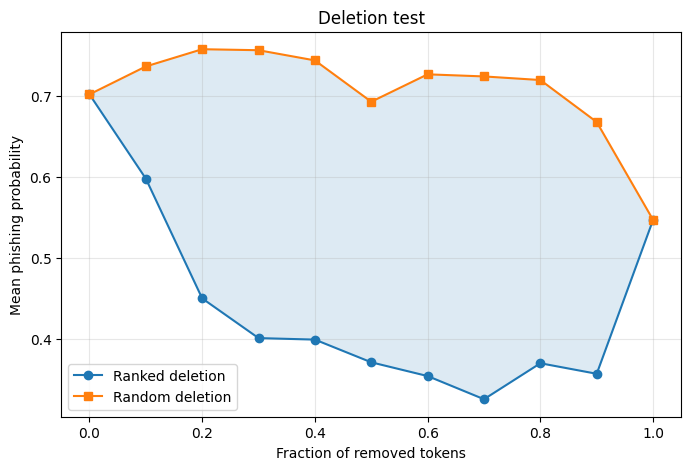

{
  "num_samples": 10,
  "ranked_auc": 0.42489386301153,
  "random_auc": 0.714839992072535,
  "auc_gap_random_minus_ranked": 0.28994612906100503
}


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(fractions, ranked_avg, marker="o", label="Ranked deletion")
plt.plot(fractions, random_avg, marker="s", label="Random deletion")
plt.fill_between(fractions, ranked_avg, random_avg, alpha=0.15)
plt.title("Deletion test")
plt.xlabel("Fraction of removed tokens")
plt.ylabel("Mean phishing probability")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(json.dumps(summary, indent=2))


## 5. How to read the result

If ranked deletion has lower AUC than random deletion, the chosen important tokens are behaviorally meaningful: removing them makes the phishing score fall faster. This is still a sanity check, not proof that LIME is perfect; removing words can create unnatural emails, and LIME remains local to one prediction.
